(array([  1.07914556e+01,  -4.25757523e+00,   1.22172884e+01,
        -1.94502085e-01,   2.78266538e-02,  -2.05536933e-03,
        -1.56630649e-02,   1.03967700e-01,  -1.67380454e-01,
        -1.42705491e-03,  -3.46818212e-03,   2.43286345e-03,
        -2.87619088e-06,   1.17095027e-04,   4.12619788e-05,
         5.60123457e-04,   3.22570570e-03,   1.76377815e-04,
         2.53648283e-03,   3.20147078e-04,  -2.56261593e-03,
        -3.43092271e-03,  -3.09554035e-03,   1.81422506e-03,
        -2.02658483e+02,  -2.90202608e-01,   6.55238474e-02]), 1)


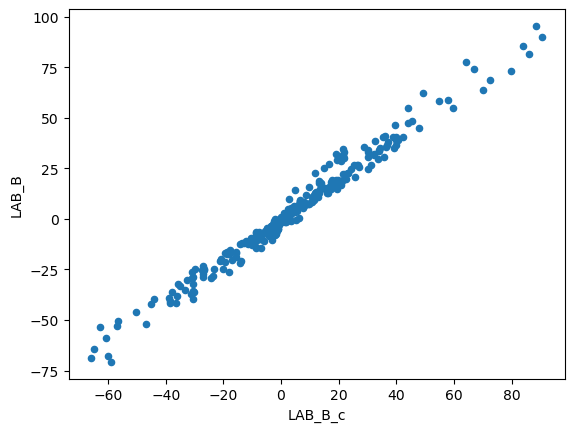

In [162]:
import numpy as np
import pandas as pd
import cv2
from scipy.optimize import leastsq
from limhescolor import *

df = pd.read_csv("all_data.csv")
df = df[["R", "G", "B", "LAB_L", "LAB_A", "LAB_B"]]

for c in ["R", "G", "B"]:
    df[c] *= 2.56
df[["LAB_L_m", "LAB_A_m", "LAB_B_m"]] = [xyz2lab(rgb2xyz(srgb, "D50"))
                             for srgb in tuple(zip(df["R"], df["G"], df["B"]))]

LAB = df[["LAB_L","LAB_A","LAB_B"]].to_numpy()
LAB_m = df[["LAB_L_m", "LAB_A_m", "LAB_B_m"]].to_numpy()
T_lab = cv2.estimateAffine3D(LAB_m, LAB)
A_lab = np.linalg.inv( T_lab[1][:,0:3] )
B_lab = T_lab[1][:,3]

def __func1d(meas, params):
    L, a, b = meas
    Lo, ao, bo, La, aL, Lb, bL, ab, ba, L2, a2, b2, L3, a3, b3, abL, aLb, bLa, aLL, bLL, Laa, baa, Lbb, abb, Ld, ad, bd = params
    return np.array([L+Lo+L*L*L2+L*L*L*L3 + La*a + Lb*b + abL*a*b + aLL*a*L + bLL*b*L + Ld/L,
                     a+ao+a*a*a2+a*a*a*a3 + aL*L + ab*b + bLa*b*L + Laa*a*L + baa*b*a + ad/a,
                     b+bo+b*b*b2+b*b*b*b3 + bL*L + ba*a + aLb*a*L + Lbb*b*L + abb*b*a + bd/b])

def __residual(params, ref, meas):
    return np.power(np.sum((np.power(ref - np.apply_along_axis(__func1d, 1, meas, params), 2)), axis=1), 0.5)

p0 = np.array([1.08027785e+01,  -4.26206386e+00,   1.22171954e+01,
        -1.94280563e-01,   2.78809332e-02,  -2.16327293e-03,
        -1.56560679e-02,   1.03780466e-01,  -1.67081299e-01,
        -1.42650817e-03,  -3.46522162e-03,   2.43230061e-03,
        -2.89535004e-06,   1.17020522e-04,   4.12434909e-05,
         5.60966089e-04,   3.22041982e-03,   1.78993406e-04,
         2.53173348e-03,   3.21684434e-04,  -2.56102016e-03,
        -3.42973383e-03,  -3.09479792e-03,   1.81464100e-03,
        -2.02981864e+02,  -2.90233212e-01,   6.57832440e-02])
p_opt = leastsq(__residual, p0, args=(LAB, LAB_m))
print(p_opt)
df[["LAB_L_c", "LAB_A_c", "LAB_B_c"]] = __fitfunc(LAB_m, p_opt[0])
df["LAB_dE"] = __residual(p_opt[0], LAB, LAB_m) # dE = 2.3 is considered "just noticeable"
df.to_csv("results.csv")

ax = df.plot.scatter(y="LAB_B", x="LAB_B_c")
